## What is Machine Learning?

### The core ML workflow (memorize this loop)

##### Data → Clean → Features → Model → Train → Evaluate → Tune → Deploy

In [18]:
# Start command line with ! to run on the terminal
!python --version
!python -m venv ../myenv

Python 3.14.2


Unable to copy 'C:\\Users\\kiran\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\venv\\scripts\\nt\\venvlauncher.exe' to 'c:\\Users\\kiran\\OneDrive\\Documents\\Learning\\ml-with-kiran\\myenv\\Scripts\\python.exe'


In [19]:
!pip install numpy pandas matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# import libraries
import numpy as np       # fast arrays & math (the backbone of everything)
import pandas as pd      # data tables — like Excel but programmable  
import matplotlib.pyplot as plt  # visualize your data


🧪 Your first homework
Try this in a Jupyter notebook or any Python environment:

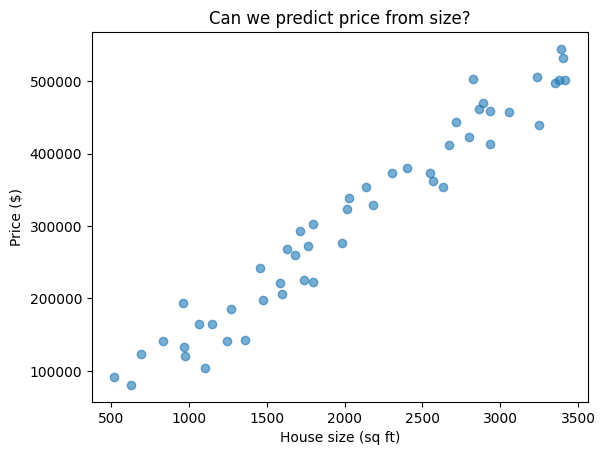

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some fake "house size vs price" data
np.random.seed(42)
house_size = np.random.randint(500, 3500, 50)          # sq ft
price = house_size * 150 + np.random.randn(50) * 30000  # noisy relationship

# Plot it
plt.scatter(house_size, price, alpha=0.6)
plt.xlabel("House size (sq ft)")
plt.ylabel("Price ($)")
plt.title("Can we predict price from size?")
plt.show()

Next up: Linear Regression — we'll build our first actual ML model from scratch, derive the math, and write it in pure Python before using any library. See you there.

# Linear Regression: building your first ML model from scratch

slope(w) 156.23
intercept(b) -10850.87
MSE: 877663111.31


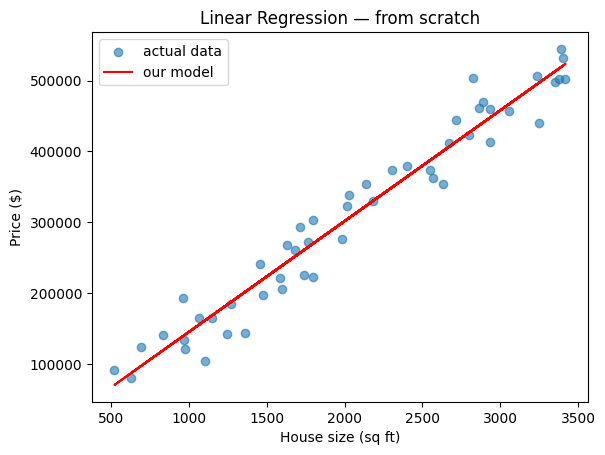

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some fake "house size vs price" data
np.random.seed(42)
x = np.random.randint(500, 3500, 50).astype(float)          # sq ft
y = x * 150 + np.random.randn(50) * 30000  # noisy relationship


# Mean Calculation
x_mean = np.mean(x)

y_mean = np.mean(y)

# Slope Calculation

# w = sum((x-x_mean) * (y-y_mean))/sum((x-x_mean)^2)

numarator = np.sum((x-x_mean) * (y-y_mean))
denominator = np.sum(np.square(x-x_mean))

w = numarator/denominator # slope

# b = y_mean * w - x_mean

# Intercept Calculation

b = y_mean - (w * x_mean) # intercept

print(f"slope(w) {w:.2f}")
print(f"intercept(b) {b:.2f}")

y_pred = w * x + b# --- evaluate ---
mse = np.mean((y - y_pred) ** 2)
print(f"MSE: {mse:.2f}")

# --- plot ---
plt.scatter(x, y, alpha=0.6, label="actual data")
plt.plot(x, y_pred, color="red", label="our model")
plt.xlabel("House size (sq ft)")
plt.ylabel("Price ($)")
plt.legend()
plt.title("Linear Regression — from scratch")
plt.show()

# Gradient Descent: the engine that powers all of modern ML

Epoch   0 | Loss: 115,099,184,524 | w= 2661.83 | b=   6213.15
Epoch  50 | Loss:  16,025,670,555 | w=85592.93 | b= 199788.21
Epoch 100 | Loss:   2,886,585,131 | w=115793.92 | b= 270282.38
Epoch 150 | Loss:   1,144,085,457 | w=126792.21 | b= 295954.22
Epoch 200 | Loss:     912,995,925 | w=130797.45 | b= 305303.12
Epoch 250 | Loss:     882,348,933 | w=132256.04 | b= 308707.71
Epoch 300 | Loss:     878,284,543 | w=132787.21 | b= 309947.56
Epoch 350 | Loss:     877,745,525 | w=132980.65 | b= 310399.07
Epoch 400 | Loss:     877,674,041 | w=133051.09 | b= 310563.50
Epoch 450 | Loss:     877,664,561 | w=133076.74 | b= 310623.38


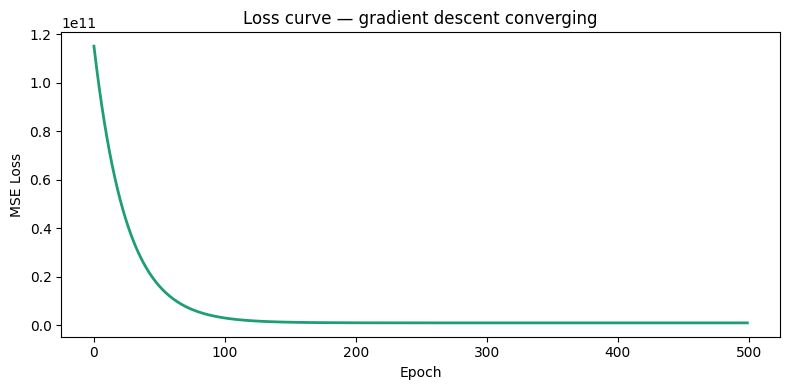


Final w: 133085.9769, b: 310644.93


In [51]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate data
np.random.seed(42)
X = np.random.randint(500, 3500, 50).astype(float)
y = X * 150 + np.random.randn(50) * 30000
n = len(X)

# 2. Normalize X so learning rate works cleanly
X_norm = (X - X.mean()) / X.std()

# 3. Initialize parameters
w, b = 0.0, 0.0
lr = 0.01          # works well on normalized data
epochs = 500
losses = []

# 4. Gradient descent loop
for epoch in range(epochs):
    y_pred = w * X_norm + b        # forward pass
    loss = np.mean((y - y_pred) ** 2)   # MSE loss
    losses.append(loss)

    dw = (2/n) * np.sum((y_pred - y) * X_norm)   # gradient of w
    db = (2/n) * np.sum(y_pred - y)               # gradient of b

    w -= lr * dw   # update w
    b -= lr * db   # update b

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:>15,.0f} | w={w:8.2f} | b={b:10.2f}")

# 5. Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#1D9E75', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss curve — gradient descent converging")
plt.tight_layout()
plt.show()

print(f"\nFinal w: {w:.4f}, b: {b:.2f}")

MSE: 877663311.46


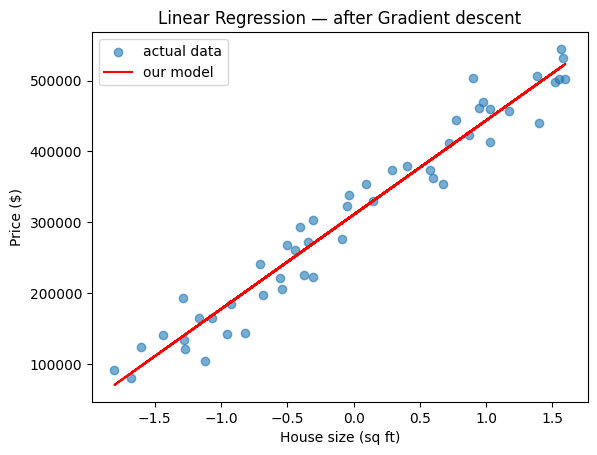

In [52]:
# Now Let's Verify the MSE
mse = np.mean((y - y_pred) ** 2)
print(f"MSE: {mse:.2f}")

# --- plot ---
plt.scatter(X_norm, y, alpha=0.6, label="actual data")
plt.plot(X_norm, y_pred, color="red", label="our model")
plt.xlabel("House size (sq ft)")
plt.ylabel("Price ($)")
plt.legend()
plt.title("Linear Regression — after Gradient descent")
plt.show()